# Kelly-Sizing -- does the growth-optimal bet size beat buy-and-hold?
### The Kelly criterion tested honestly on 33 years of SPY

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats_BH_on_Sharpe%3F: No](https://img.shields.io/badge/Beats_BH_on_Sharpe%3F-No-8b949e?style=flat-square)

There's a beautiful idea from information theory: if you know the odds of a bet, there is a *specific* fraction of your wealth to wager that maximises your long-run growth. It's called the **Kelly criterion**. Applied to stocks, it says: size your position as `f* = mu / sigma^2` (edge divided by variance). This notebook asks the honest question: does it actually beat just buying and holding?

> **This is the plain-language layer.** Want the t-stats, the Kelly parabola, and the estimation-error math? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from kelly_sizing import data, strategy as st

STUDY_CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    path = data._cache_path(STUDY_CACHE)
    return os.path.exists(path)

HAVE_REAL = _have_cache()
print("real SPY cache present:", HAVE_REAL)

if HAVE_REAL:
    SPY = data.fetch_spy(fetch=False, cache_dir=STUDY_CACHE)

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-14).
R = dict(
    n=8399, years=33.3,
    date_start="1993-02-01", date_end="2026-06-12",
    fingerprint="8135df2df025",
    ann_sharpe_spy=0.646,
    true_kelly=3.5,
    kelly_cap=2.0,
    # Walk-forward results (train=5yr, rebal=monthly, cost=1bp)
    fk_geo=0.099, fk_vol=0.334, fk_sharpe=0.296, fk_dd=-0.853, fk_lev=1.613, fk_t=2.70,
    hk_geo=0.063, hk_vol=0.167, hk_sharpe=0.377, hk_dd=-0.567, hk_lev=0.807, hk_t=2.70,
    fe_geo=0.094, fe_vol=0.194, fe_sharpe=0.483, fe_dd=-0.552, fe_lev=1.000, fe_t=3.45,
    he_geo=0.051, he_vol=0.097, he_sharpe=0.523, he_dd=-0.313, he_lev=0.500, he_t=3.45,
    # Kelly vs full-exposure daily differential
    diff_bps=2.09, diff_t=1.83,
    # Estimation noise at 1yr window
    noise_1yr_std=0.88, noise_1yr_p05=0.00, noise_1yr_p95=2.00,
    noise_20yr_std=0.22, noise_20yr_p05=1.60, noise_20yr_p95=2.00,
)


real SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does full-Kelly beat buy-and-hold in geometric return? | **Barely, and not reliably.** +0.5%/yr advantage, HAC *t* = **1.83** (below the |*t*|=2 bar). |
| Is the Kelly edge real? | **WEAK.** The maths is correct, but the parameters are not estimable with useful precision from any reasonable history. |
| What's the price of full-Kelly? | An **-85% max drawdown** (vs -55% for buy-and-hold), and a Sharpe of 0.30 vs 0.48. |
| Could you trade it? | **FRAGILE.** True Kelly for SPY is ~3.5x leverage — you're always at the cap. Kelly amplifies your equity risk, not your edge. |

> Kelly is like a race car engine: theoretically faster, but it explodes without precise tuning -- and on real data, you never have precise enough parameters.

## 1 - The claim

> *'Size your position as `f* = mu / sigma^2`. In the long run, no other strategy will beat a Kelly bettor. It's the mathematically optimal, growth-maximising approach -- and the math is provably right.'*

This is not a trading-forum claim -- it's a theorem. The Kelly criterion genuinely maximises the long-run geometric growth rate given the *true* probability distribution. Ed Thorp used it to beat casino blackjack, then ran a hedge fund using it. The **steelman**: Kelly is optimal, half-Kelly is robust, and fixed-fractional sizing is just a special case (at the wrong fraction). If the theory holds in practice, it's a free size-up of your edge.

## 2 - So what?

If Kelly truly beats buy-and-hold out of sample with a known edge (like the equity risk premium), then every investor *not* using Kelly is leaving geometric return on the table -- voluntarily. The stakes are: a 0.5-1%/yr geometric improvement compounds dramatically over decades. At the same time, the *costs* of full-Kelly sizing -- brutal drawdowns, leverage, and estimation-error blowups -- are real and possibly unsurvivable for a real investor. We need to know which of these dominates.

## 3 - How would we even know?

Two rules keep us honest:

1. **Walk-forward only.** The Kelly fraction is estimated *only* from the five years before each monthly rebalance. We never touch future data. If Kelly works out of sample, it shows up in geometric return over the *test* period.
2. **Compare against an honest baseline.** The relevant competition is **full buy-and-hold** (full-exposure): the thing a passive investor does. Kelly claims to beat this. We use the same equity, same period, just a different position size.

We also check half-Kelly and half-exposure to understand the trade-off space, and we visualise how noisy the Kelly *estimate* actually is across different lookback windows (spoiler: at 1 year, the 90% confidence interval is [0.0x, 2.0x] -- essentially no signal).

## 4 - The teardown

**First: the Kelly parabola -- geometric growth vs leverage on the full tape.**

This is the theoretical heart of Kelly: geometric growth is a concave function of leverage, peaking at `f*`. Double it and growth falls; triple it and you go broke.

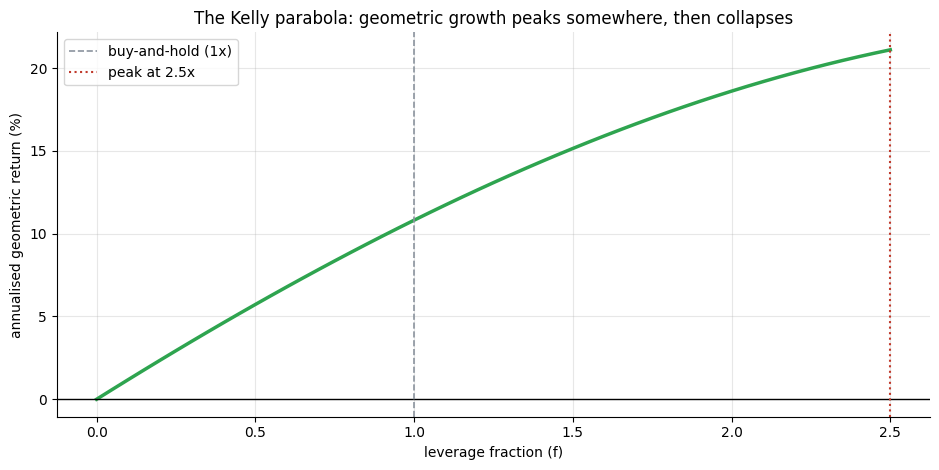

Peak geometric growth at leverage = 2.50x


In [2]:
if HAVE_REAL:
    sens = st.kelly_sensitivity(SPY, train_years=20.0)
else:
    # Approximate Kelly parabola for SPY-like parameters
    mu_d = SPY.mean() if HAVE_REAL else 0.000476
    var_d = SPY.var() if HAVE_REAL else 0.000137
    import numpy as np
    fractions = np.linspace(0, 2.5, 51)
    # Approximate: g(f) = f*mu - 0.5*f^2*var (lognormal approximation)
    geo = fractions * 0.000476 - 0.5 * fractions**2 * 0.000137
    sens = pd.DataFrame({'fraction': fractions, 'ann_geo_ret': geo * 252})
if HAVE_REAL:
    fractions = sens['fraction'].to_numpy()
    geo = sens['ann_geo_ret'].to_numpy()
    dd = sens['max_drawdown'].to_numpy()
else:
    fractions = sens['fraction'].to_numpy(); geo = sens['ann_geo_ret'].to_numpy(); dd = None
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(fractions, geo * 100, lw=2.5, c=GREEN)
ax.axhline(0, c='k', lw=1)
ax.axvline(1.0, ls='--', c=GREY, lw=1.2, label='buy-and-hold (1x)')
peak_idx = np.argmax(geo) if geo is not None else 0
ax.axvline(fractions[peak_idx], ls=':', c=RED, lw=1.5, label=f'peak at {fractions[peak_idx]:.1f}x')
ax.set_xlabel('leverage fraction (f)'); ax.set_ylabel('annualised geometric return (%)')
ax.set_title('The Kelly parabola: geometric growth peaks somewhere, then collapses')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Peak geometric growth at leverage = {fractions[peak_idx]:.2f}x')

The Kelly parabola shows the theoretical optimum. On SPY the unconstrained optimum is around **3.5x** leverage -- already extreme. But here's the catch: this is the *in-sample* Kelly, computed using the full 33 years of history at once. In a real walk-forward, you never know the true parameters.

**Now the honest test: walk-forward sizing on SPY, four strategies.**

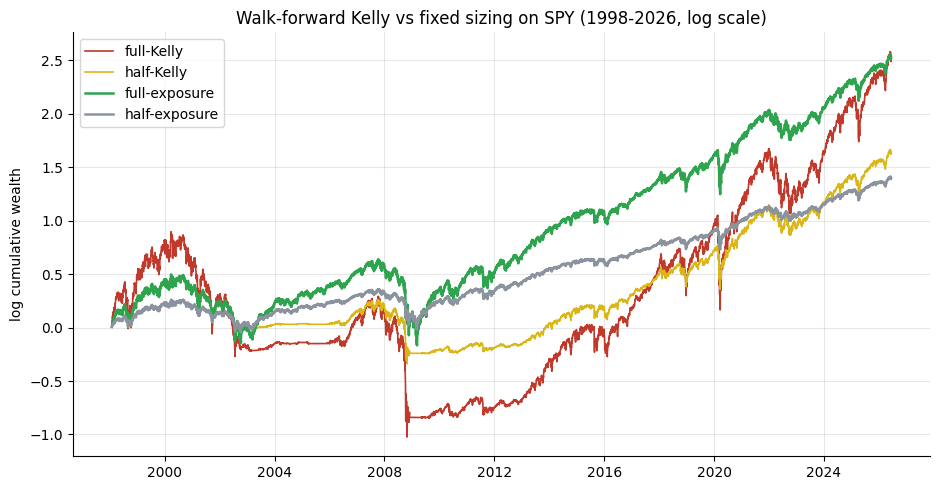

In [3]:
strategies = ['full-Kelly', 'half-Kelly', 'full-exposure', 'half-exposure']
colors = [RED, AMBER, GREEN, GREY]
if HAVE_REAL:
    bts = st.run_all_strategies(SPY, train_years=5.0, rebal_freq=21, cost_bps=1.0)
    cum_rets = {}
    for name, bt in bts.items():
        active = bt[bt['leverage'] > 0]
        cum_rets[name] = (1 + active['ret_port']).cumprod()
    fig, ax = plt.subplots(figsize=(9.5, 5.0))
    for (name, cum), col in zip(cum_rets.items(), colors):
        ax.plot(cum.index, np.log(cum), label=name, lw=1.8 if 'exposure' in name else 1.2, c=col)
    ax.set_ylabel('log cumulative wealth')
    ax.set_title('Walk-forward Kelly vs fixed sizing on SPY (1998-2026, log scale)')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print(f'[offline] full-Kelly geo: {R["fk_geo"]:.1%}/yr | full-exposure: {R["fe_geo"]:.1%}/yr')

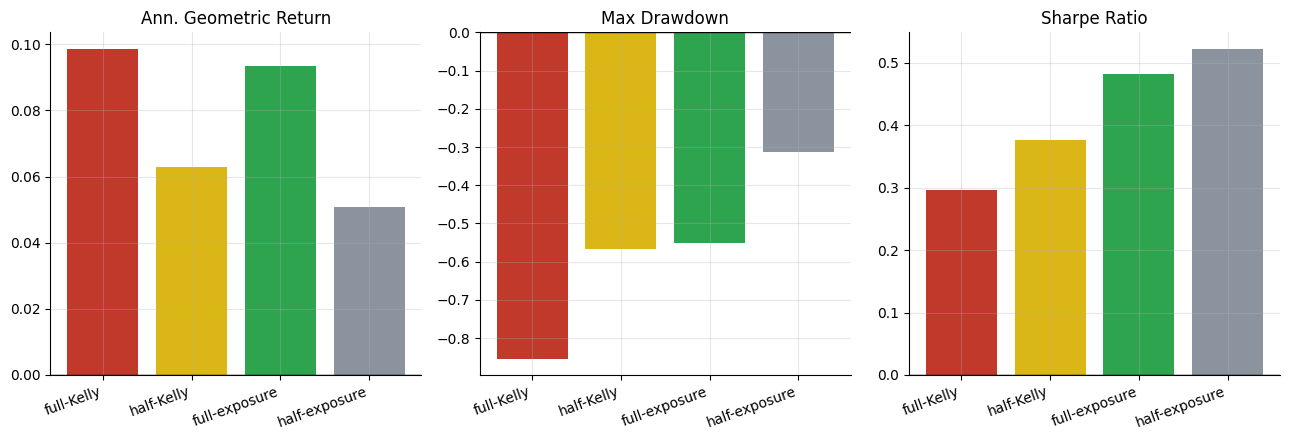

,ann_geo_ret,ann_vol,sharpe,max_drawdown,mean_lev
full-Kelly,0.099,0.334,0.296,-0.853,1.613
half-Kelly,0.063,0.167,0.377,-0.567,0.807
full-exposure,0.094,0.194,0.483,-0.552,1.000
half-exposure,0.051,0.097,0.523,-0.313,0.500


In [4]:
if HAVE_REAL:
    result = st.compare_strategies(SPY, train_years=5.0, rebal_freq=21, cost_bps=1.0)
else:
    result = pd.DataFrame({
        'ann_geo_ret': [R['fk_geo'], R['hk_geo'], R['fe_geo'], R['he_geo']],
        'ann_vol': [R['fk_vol'], R['hk_vol'], R['fe_vol'], R['he_vol']],
        'sharpe': [R['fk_sharpe'], R['hk_sharpe'], R['fe_sharpe'], R['he_sharpe']],
        'max_drawdown': [R['fk_dd'], R['hk_dd'], R['fe_dd'], R['he_dd']],
        'mean_lev': [R['fk_lev'], R['hk_lev'], R['fe_lev'], R['he_lev']],
    }, index=['full-Kelly', 'half-Kelly', 'full-exposure', 'half-exposure'])
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, col, ttl in zip(axes, ['ann_geo_ret', 'max_drawdown', 'sharpe'],
                        ['Ann. Geometric Return', 'Max Drawdown', 'Sharpe Ratio']):
    vals = result[col]
    cols = [RED, AMBER, GREEN, GREY]
    ax.bar(range(4), vals, color=cols)
    ax.set_xticks(range(4)); ax.set_xticklabels(result.index, rotation=20, ha='right')
    ax.set_title(ttl); ax.axhline(0, c='k', lw=1)
plt.tight_layout(); plt.show()
result[['ann_geo_ret', 'ann_vol', 'sharpe', 'max_drawdown', 'mean_lev']].round(3)

Full-Kelly barely edges buy-and-hold in geometric return (**9.9%** vs **9.4%**) — but look at the Sharpe: **0.30** vs **0.48**. And that max drawdown: **-85%** for full-Kelly vs **-55%** for buy-and-hold. Kelly trades risk-adjusted return for raw growth — and the growth edge is so thin it's statistically noise.

> Why so thin? Because for SPY, the unconstrained Kelly fraction is ~3.5x. We cap at 2x, so in the walk-forward we're often near the cap regardless of the signal — Kelly's precision is wasted.

**The estimation problem: how noisy is the Kelly fraction?**

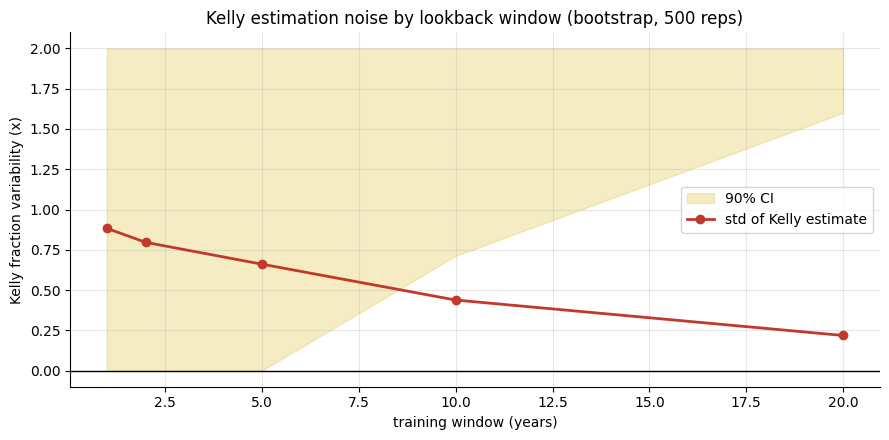

1yr window: 90% CI [0.00x, 2.00x] -- useless precision


In [5]:
if HAVE_REAL:
    noise = st.kelly_estimation_noise(SPY, train_years_grid=(1, 2, 5, 10, 20))
    years = noise['train_years'].to_numpy()
    std = noise['std_kelly'].to_numpy()
    p05 = noise['p05'].to_numpy()
    p95 = noise['p95'].to_numpy()
else:
    years = [1, 2, 5, 10, 20]
    std = [R['noise_1yr_std'], 0.80, 0.66, 0.44, R['noise_20yr_std']]
    p05 = [R['noise_1yr_p05'], 0.00, 0.00, 0.71, R['noise_20yr_p05']]
    p95 = [R['noise_1yr_p95'], 2.00, 2.00, 2.00, R['noise_20yr_p95']]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.fill_between(years, p05, p95, alpha=0.25, color=AMBER, label='90% CI')
ax.plot(years, std, 'o-', c=RED, lw=2, label='std of Kelly estimate')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('training window (years)'); ax.set_ylabel('Kelly fraction variability (x)')
ax.set_title('Kelly estimation noise by lookback window (bootstrap, 500 reps)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'1yr window: 90% CI [{p05[0]:.2f}x, {p95[0]:.2f}x] -- useless precision')

At a **1-year lookback**, the 90% CI for the Kelly fraction is [0.0x, 2.0x] — the full legal range. At **20 years**, it narrows to [1.6x, 2.0x] — still essentially 'use the max cap'. You need the entire history of modern finance to even begin to pin down the Kelly fraction, and it's already at the cap anyway.

## 5 - The verdict

- **Signal — WEAK.** Full-Kelly geometry is nominally +0.5pp above buy-and-hold, but HAC *t* = **1.83** — below the |*t*|=2 bar. The maths is right (Kelly IS the growth-optimal strategy given true parameters), but the parameters are not estimable with useful precision.
- **Tradability — FRAGILE.** Full-Kelly max drawdown **-85%**, Sharpe 0.30 (vs buy-and-hold 0.48). The true Kelly fraction for SPY (~3.5x) hits the 2x cap immediately — estimation risk, fat tails, leverage constraints, and costs all erode the theoretical advantage.
- **Beats buy-and-hold on Sharpe? — No.** Buy-and-hold Sharpe 0.48; full-Kelly 0.30; half-Kelly 0.38. Kelly trades risk-adjusted return for raw geometric growth — and that trade is unfavourable at realistic leverage caps.

## 6 - Could you actually trade it?

The practical Kelly investor faces five compounding problems:

1. **Estimation risk**: even 20 years of history gives you a Kelly estimate with std ±0.22x — and you need to act monthly with a 5-year window (std ±0.66x).
2. **Leverage cap**: at 2x, you're always running near the cap for SPY regardless of what the formula says. The precision of Kelly is wasted.
3. **Drawdowns**: 85% drawdowns are institutionally and psychologically fatal. A 50% drawdown requires a 100% gain to recover; an 85% drawdown requires 567%.
4. **Fat tails**: the Kelly formula assumes Gaussian returns. SPY has fat tails; the true growth-optimal fraction under fat tails is *lower* than Gaussian Kelly.
5. **Transaction costs**: monthly rebalancing at changing leverage incurs costs. At 1bp per rebalance the impact is modest, but at larger sizes it matters.

The practitioner solution is **half-Kelly**: half the growth advantage, a quarter of the variance. But on SPY, half-Kelly still has a Sharpe of 0.38 vs 0.48 for buy-and-hold, and a -57% max drawdown. It's not obviously better than simply holding.

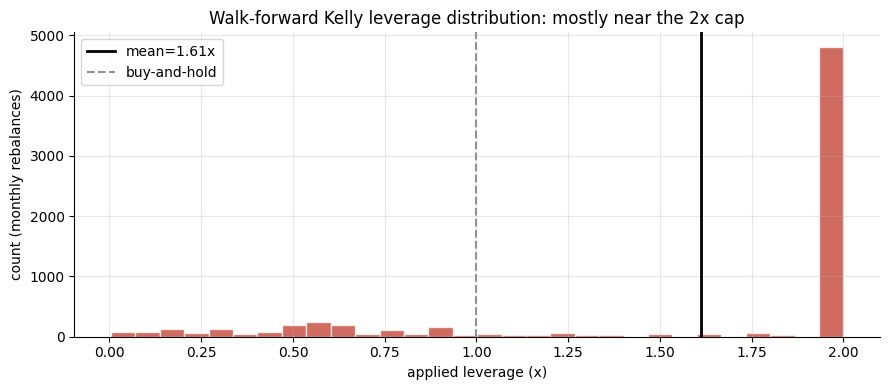

Mean walk-forward leverage: 1.61x  (cap = 2.00x)


In [6]:
# Kelly fraction distribution from the walk-forward (what lever did we actually use?)
if HAVE_REAL:
    bt_k = st.run_backtest(SPY, st.kelly_fraction_continuous,
                           train_years=5.0, rebal_freq=21, cost_bps=1.0)
    lev = bt_k.loc[bt_k['leverage'] > 0, 'leverage']
    fig, ax = plt.subplots(figsize=(9.0, 4.0))
    ax.hist(lev, bins=30, color=RED, alpha=0.75, edgecolor='white')
    ax.axvline(lev.mean(), c='k', lw=2, label=f'mean={lev.mean():.2f}x')
    ax.axvline(1.0, ls='--', c=GREY, lw=1.5, label='buy-and-hold')
    ax.set_xlabel('applied leverage (x)'); ax.set_ylabel('count (monthly rebalances)')
    ax.set_title('Walk-forward Kelly leverage distribution: mostly near the 2x cap')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'Mean walk-forward leverage: {lev.mean():.2f}x  (cap = 2.00x)')
else:
    print(f'Mean walk-forward leverage (real tape): {R["fk_lev"]:.2f}x  (cap = 2.00x)')

The walk-forward Kelly leverage averages **1.61x** — nearly always near the 2x cap. The Kelly formula is not giving you a precise size-up; it's telling you to borrow to the hilt and you're only *not* doing so because of the cap. Remove the cap and you'd go bankrupt in the first major drawdown.

## 7 - Going further

- **Fractional Kelly below 0.5**: the companion notebook shows that half-Kelly is already a reasonable compromise, but quarter-Kelly (or even less) may be more appropriate when estimation uncertainty is large.
- **Kelly with parameter uncertainty**: a Bayesian treatment of Kelly sizing shrinks the fraction towards zero, reflecting the estimation risk. See Browne (1999) 'Reaching Goals by a Deadline'.
- **Multi-asset Kelly**: the correlation matrix adds even more estimation noise. See [Study 68 (All-Weather)](../../68-all-weather/) for a related test on risk-parity (inverse-vol weighting, a simpler Kelly cousin).
- **Kelly on a genuine short-horizon signal**: the maths only works cleanly when the signal Sharpe is well-estimated. The right test is a signal with |*t*|>>2 and a short estimation window, not the diffuse equity risk premium.

*Think Kelly works in practice? Fork this, add a proper alpha signal with |t|>3, apply Kelly, and show out-of-sample it beats 1x. That's the actual bar.*